In [3]:
import pandas as pd

In [4]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],

    "Test Accuracy": [
        0.9192037470472596,
        0.9285714285714286,
        0.9988290398126464,
        0.9988290398126464,
        0.9976580796252927
    ],

    "Test Precision": [
        0.9215328470153284,
        0.9257246376811594,
        0.9981203007518797,
        0.9981203007518797,
        0.9981167608286252
    ],

    "Test Recall": [
        0.9510357815442562,
        0.9623352165725048,
        1.0,
        1.0,
        0.9981167608286252
    ],

    "Test F1": [
        0.936051899073216,
        0.9436749769159741,
        0.9990592662276576,
        0.9990592662276576,
        0.9981167608286252
    ],

    "Test ROC-AUC": [
        0.9750339624401648,
        0.9820684146391235,
        0.9999912543072537,
        0.9999941695381691,
        0.999825086145074
    ]
})

In [5]:
model_comparison

,Model,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC
0,Logistic Regression,0.919204,0.921533,0.951036,0.936052,0.975034
1,KNN,0.928571,0.925725,0.962335,0.943675,0.982068
2,Decision Tree,0.998829,0.998120,1.000000,0.999059,0.999991
3,Random Forest,0.998829,0.998120,1.000000,0.999059,0.999994
4,XGBoost,0.997658,0.998117,0.998117,0.998117,0.999825


In [6]:
model_comparison.sort_values(
    "Test ROC-AUC",
    ascending=False
)

,Model,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC
3,Random Forest,0.998829,0.998120,1.000000,0.999059,0.999994
2,Decision Tree,0.998829,0.998120,1.000000,0.999059,0.999991
4,XGBoost,0.997658,0.998117,0.998117,0.998117,0.999825
1,KNN,0.928571,0.925725,0.962335,0.943675,0.982068
0,Logistic Regression,0.919204,0.921533,0.951036,0.936052,0.975034


In [7]:
X_train = joblib.load("../data/X_train_raw.joblib")
X_test = joblib.load("../data/X_test_raw.joblib")

y_train = joblib.load("../data/y_train.joblib")
y_test = joblib.load("../data/y_test.joblib")


In [8]:
import joblib

rf_pipeline = joblib.load(
    "../models/random_forest_final_pipeline.pkl"
)

print(rf_pipeline)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['no_of_dependents',
                                                   ' income_annum',
                                                   ' loan_amount', ' loan_term',
                                                   ' cibil_score',
                                                   ' residential_assets_value',
                                                   ' commercial_assets_value',
                                                   ' luxury_assets_value',
                                                   ' bank_asset_value',
                                                   ' total_assets',
                                                   ' loan_to_income_ratio',
                                                   ' asset_to_loan_ratio',
                                                   ' asset_to_income_ratio']),
 

In [9]:
dt_pipeline = joblib.load(
    "../models/decision_tree_final_pipeline.pkl"
)

print(dt_pipeline)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['no_of_dependents',
                                                   ' income_annum',
                                                   ' loan_amount', ' loan_term',
                                                   ' cibil_score',
                                                   ' residential_assets_value',
                                                   ' commercial_assets_value',
                                                   ' luxury_assets_value',
                                                   ' bank_asset_value',
                                                   ' total_assets',
                                                   ' loan_to_income

In [10]:
y_train = y_train.map({
    "Rejected": 0,
    "Approved": 1
})

y_test = y_test.map({
    "Rejected": 0,
    "Approved": 1
})

In [11]:
from sklearn.metrics import accuracy_score

dt_loaded_accuracy = accuracy_score(
    y_test,
    y_pred_dt
)

print("Loaded Decision Tree Accuracy:",
      dt_loaded_accuracy)

NameError: name 'y_pred_dt' is not defined

In [ ]:
y_pred_dt = dt_pipeline.predict(X_test)

print(y_pred_dt[:10])

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [12]:
y_prob_dt = dt_pipeline.predict_proba(X_test)[:, 1]

In [13]:
print("Decision Tree Test Accuracy :", accuracy_score(y_test, y_pred_dt))

print("Decision Tree Test Precision:", precision_score(y_test, y_pred_dt))

print("Decision Tree Test Recall   :", recall_score(y_test, y_pred_dt))

print("Decision Tree Test F1       :", f1_score(y_test, y_pred_dt))

print("Decision Tree Test ROC-AUC  :", roc_auc_score(y_test, y_prob_dt))


NameError: name 'y_pred_dt' is not defined

In [14]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

print(cm_dt)

NameError: name 'confusion_matrix' is not defined

In [15]:
print(classification_report(y_test, y_pred_dt))

NameError: name 'classification_report' is not defined

In [23]:
rf_pipeline = joblib.load(
    "../models/random_forest_final_pipeline.pkl"
)

In [33]:
y_pred_rf = rf_pipeline.predict(X_test)

print(y_pred_rf[:10])

[1 1 1 0 1 0 0 1 1 1]


In [25]:
y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]

print(y_prob_rf[:10])

[1. 1. 1. 0. 1. 0. 0. 1. 1. 1.]


In [26]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Random Forest Test Accuracy :",
      accuracy_score(y_test, y_pred_rf))

print("Random Forest Test Precision:",
      precision_score(y_test, y_pred_rf))

print("Random Forest Test Recall   :",
      recall_score(y_test, y_pred_rf))

print("Random Forest Test F1       :",
      f1_score(y_test, y_pred_rf))

print("Random Forest Test ROC-AUC  :",
      roc_auc_score(y_test, y_prob_rf))

Random Forest Test Accuracy : 0.9988290398126464
Random Forest Test Precision: 0.9981203007518797
Random Forest Test Recall   : 1.0
Random Forest Test F1       : 0.9990592662276576
Random Forest Test ROC-AUC  : 0.9999941695381691


In [27]:
from sklearn.metrics import confusion_matrix

cm_rf = confusion_matrix(
    y_test,
    y_pred_rf
)

print(cm_rf)

[[322   1]
 [  0 531]]


In [28]:
xgb_pipeline = joblib.load(
    "../models/xgboost_final_pipeline.pkl"
)

In [29]:
y_pred_xgb = xgb_pipeline.predict(X_test)

print(y_pred_xgb[:10])

[1 1 1 0 1 0 0 1 1 1]


In [30]:
y_prob_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]

print(y_prob_xgb[:10])

[0.9994973  0.99974376 0.9998123  0.00362409 0.9999156  0.00112802
 0.00576278 0.99972576 0.9991265  0.999757  ]


In [31]:
roc_auc_score(y_test, y_prob_xgb)

0.9999825086145074

In [32]:
from sklearn.metrics import roc_auc_score

xgb_test_roc_auc = roc_auc_score(
    y_test,
    y_prob_xgb
)

print("XGBoost Test ROC-AUC :", xgb_test_roc_auc)

XGBoost Test ROC-AUC : 0.9999825086145074


In [33]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("XGBoost Test Accuracy :",
      accuracy_score(y_test, y_pred_xgb))

print("XGBoost Test Precision:",
      precision_score(y_test, y_pred_xgb))

print("XGBoost Test Recall   :",
      recall_score(y_test, y_pred_xgb))

print("XGBoost Test F1       :",
      f1_score(y_test, y_pred_xgb))

print("XGBoost Test ROC-AUC  :",
      roc_auc_score(y_test, y_prob_xgb))

XGBoost Test Accuracy : 0.9976580796252927
XGBoost Test Precision: 0.9981167608286252
XGBoost Test Recall   : 0.9981167608286252
XGBoost Test F1       : 0.9981167608286252
XGBoost Test ROC-AUC  : 0.9999825086145074


In [34]:
from sklearn.metrics import confusion_matrix

cm_xgb = confusion_matrix(
    y_test,
    y_pred_xgb
)

print(cm_xgb)

[[322   1]
 [  1 530]]


In [35]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_xgb
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       323
           1       1.00      1.00      1.00       531

    accuracy                           1.00       854
   macro avg       1.00      1.00      1.00       854
weighted avg       1.00      1.00      1.00       854



# final eveluation tabel 

In [20]:
model_results = {
    "Logistic Regression": {
        "Accuracy": 0.919204,
        "Precision": 0.921533,
        "Recall": 0.951036,
        "F1": 0.936052,
        "ROC-AUC": 0.975034
    },

    "KNN": {
        "Accuracy": 0.928571,
        "Precision": 0.925725,
        "Recall": 0.962335,
        "F1": 0.943675,
        "ROC-AUC": 0.982068
    },

    "Decision Tree": {
        "Accuracy": 0.998829,
        "Precision": 0.998120,
        "Recall": 1.000000,
        "F1": 0.999059,
        "ROC-AUC": 0.999991
    },

    "Random Forest": {
        "Accuracy": 0.998829,
        "Precision": 0.998120,
        "Recall": 1.000000,
        "F1": 0.999059,
        "ROC-AUC": 0.999994
    },

    "XGBoost": {
        "Accuracy": 0.997658,
        "Precision": 0.998117,
        "Recall": 0.998117,
        "F1": 0.998117,
        "ROC-AUC": 0.999983
    }
}

In [21]:
import pandas as pd

comparison_df = pd.DataFrame(model_results).T

comparison_df

,Accuracy,Precision,Recall,F1,ROC-AUC
Logistic Regression,0.919204,0.921533,0.951036,0.936052,0.975034
KNN,0.928571,0.925725,0.962335,0.943675,0.982068
Decision Tree,0.998829,0.998120,1.000000,0.999059,0.999991
Random Forest,0.998829,0.998120,1.000000,0.999059,0.999994
XGBoost,0.997658,0.998117,0.998117,0.998117,0.999983


In [22]:
best_model_name = comparison_df["ROC-AUC"].idxmax()
best_roc_auc = comparison_df["ROC-AUC"].max()

print("Best Model :", best_model_name)
print("Best ROC-AUC:", best_roc_auc)


Best Model : Random Forest
Best ROC-AUC: 0.999994


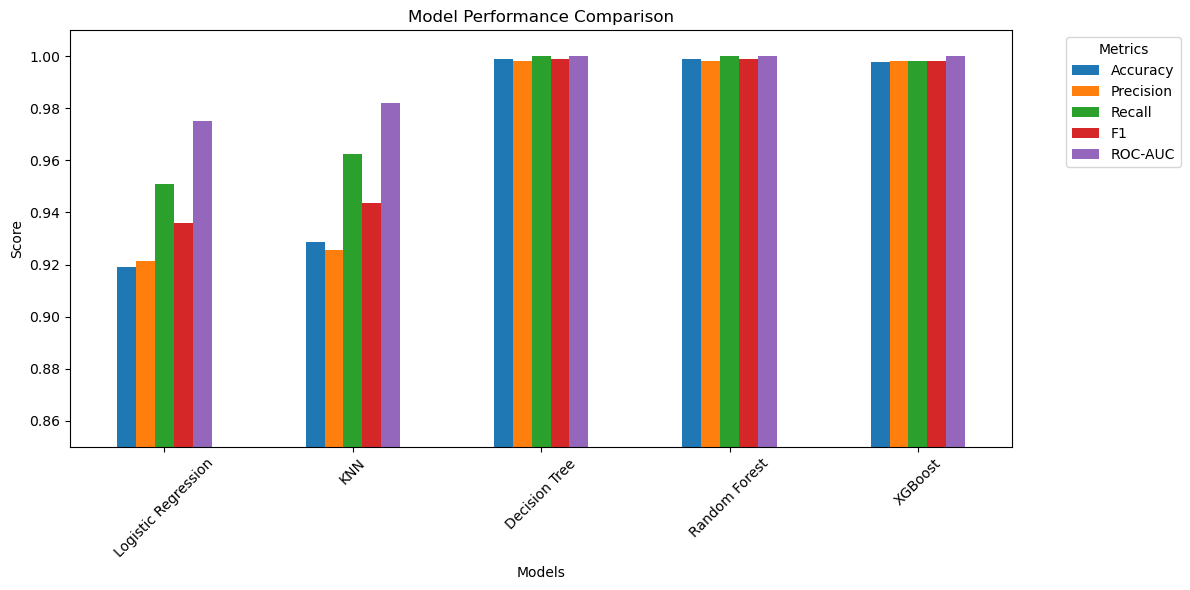

In [23]:
import matplotlib.pyplot as plt

comparison_df.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Model Performance Comparison")
plt.xlabel("Models")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.ylim(0.85, 1.01)
plt.legend(
    title="Metrics",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()

In [24]:
final_ranking = comparison_df.sort_values(
    by="ROC-AUC",
    ascending=False
)

final_ranking

,Accuracy,Precision,Recall,F1,ROC-AUC
Random Forest,0.998829,0.998120,1.000000,0.999059,0.999994
Decision Tree,0.998829,0.998120,1.000000,0.999059,0.999991
XGBoost,0.997658,0.998117,0.998117,0.998117,0.999983
KNN,0.928571,0.925725,0.962335,0.943675,0.982068
Logistic Regression,0.919204,0.921533,0.951036,0.936052,0.975034


In [25]:
final_model = rf_pipeline

print(final_model)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['no_of_dependents',
                                                   ' income_annum',
                                                   ' loan_amount', ' loan_term',
                                                   ' cibil_score',
                                                   ' residential_assets_value',
                                                   ' commercial_assets_value',
                                                   ' luxury_assets_value',
                                                   ' bank_asset_value',
                                                   ' total_assets',
                                                   ' loan_to_income_ratio',
                                                   ' asset_to_loan_ratio',
                                                   ' asset_to_income_ratio']),
 

In [26]:
print("Final Model:", best_model_name)
print("Final ROC-AUC:", best_roc_auc)

Final Model: Random Forest
Final ROC-AUC: 0.999994


In [27]:
import joblib

final_model_path = "../models/creditwise_final_model.pkl"

joblib.dump(
    final_model,
    final_model_path
)

print("Final model saved to:", final_model_path)

Final model saved to: ../models/creditwise_final_model.pkl


In [28]:
import os

print("File exists:", os.path.exists(final_model_path))
print("File size:", os.path.getsize(final_model_path), "bytes")

File exists: True
File size: 287666 bytes


In [29]:
final_model_loaded = joblib.load(
    "../models/creditwise_final_model.pkl"
)

print(final_model_loaded)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['no_of_dependents',
                                                   ' income_annum',
                                                   ' loan_amount', ' loan_term',
                                                   ' cibil_score',
                                                   ' residential_assets_value',
                                                   ' commercial_assets_value',
                                                   ' luxury_assets_value',
                                                   ' bank_asset_value',
                                                   ' total_assets',
                                                   ' loan_to_income_ratio',
                                                   ' asset_to_loan_ratio',
                                                   ' asset_to_income_ratio']),
 

In [30]:
final_predictions = final_model_loaded.predict(X_test)

print(final_predictions[:10])

[1 1 1 0 1 0 0 1 1 1]


In [31]:
final_accuracy = accuracy_score(
    y_test,
    final_predictions
)

print("Final Model Accuracy:", final_accuracy)

Final Model Accuracy: 0.9988290398126464


In [34]:
print(
    "Predictions identical:",
    (final_predictions == y_pred_rf).all()
)

Predictions identical: True


# final

In [35]:
final_model_loaded = joblib.load(
    "../models/creditwise_final_model.pkl"
)

print(final_model_loaded)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['no_of_dependents',
                                                   ' income_annum',
                                                   ' loan_amount', ' loan_term',
                                                   ' cibil_score',
                                                   ' residential_assets_value',
                                                   ' commercial_assets_value',
                                                   ' luxury_assets_value',
                                                   ' bank_asset_value',
                                                   ' total_assets',
                                                   ' loan_to_income_ratio',
                                                   ' asset_to_loan_ratio',
                                                   ' asset_to_income_ratio']),
 

In [36]:
final_predictions = final_model_loaded.predict(X_test)

print(final_predictions[:10])

[1 1 1 0 1 0 0 1 1 1]


In [37]:
final_accuracy = accuracy_score(
    y_test,
    final_predictions
)

print("Final Model Accuracy:", final_accuracy)

Final Model Accuracy: 0.9988290398126464


In [38]:
predictions_identical = (
    final_predictions == y_pred_rf
).all()

print(
    "Predictions identical:",
    predictions_identical
)


Predictions identical: True


In [39]:
import pandas as pd

new_application = pd.DataFrame({
    "no_of_dependents": [2],
    " education": [" Graduate"],
    " self_employed": [" No"],
    " income_annum": [500000],
    " loan_amount": [1500000],
    " loan_term": [10],
    " cibil_score": [750],
    " residential_assets_value": [3000000],
    " commercial_assets_value": [1000000],
    " luxury_assets_value": [500000],
    " bank_asset_value": [1000000],
    " total_assets": [5500000],
    " loan_to_income_ratio": [3.0],
    " asset_to_loan_ratio": [3.67],
    " asset_to_income_ratio": [11.0]
})

print(new_application)

   no_of_dependents  education  self_employed   income_annum   loan_amount  \
0                 2   Graduate             No         500000       1500000   

    loan_term   cibil_score   residential_assets_value  \
0          10           750                    3000000   

    commercial_assets_value   luxury_assets_value   bank_asset_value  \
0                   1000000                500000            1000000   

    total_assets   loan_to_income_ratio   asset_to_loan_ratio  \
0        5500000                    3.0                  3.67   

    asset_to_income_ratio  
0                    11.0  


In [40]:
prediction = final_model_loaded.predict(
    new_application
)

print("Prediction:", prediction)

Prediction: [1]


In [41]:
prediction = final_model_loaded.predict(
    new_application
)[0]

approval_probability = final_model_loaded.predict_proba(
    new_application
)[0][1]

if prediction == 1:
    status = "Approved"
else:
    status = "Rejected"

print("Loan Status:", status)
print(
    "Approval Probability:",
    round(approval_probability * 100, 2),
    "%"
)

Loan Status: Approved
Approval Probability: 99.08 %
